In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

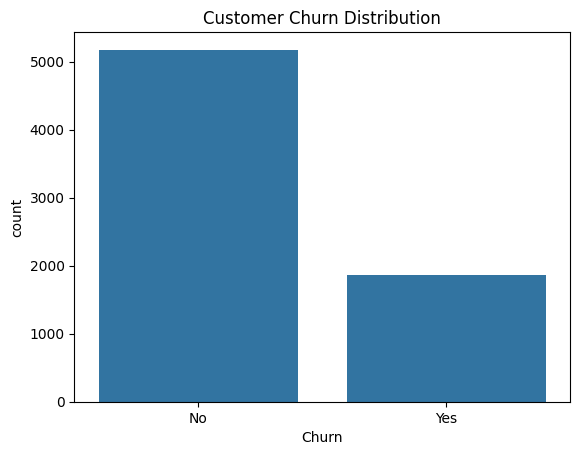

In [8]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

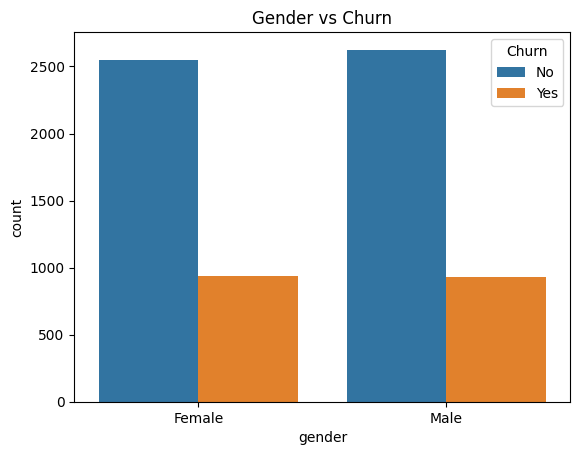

In [9]:
sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Churn")

plt.show()

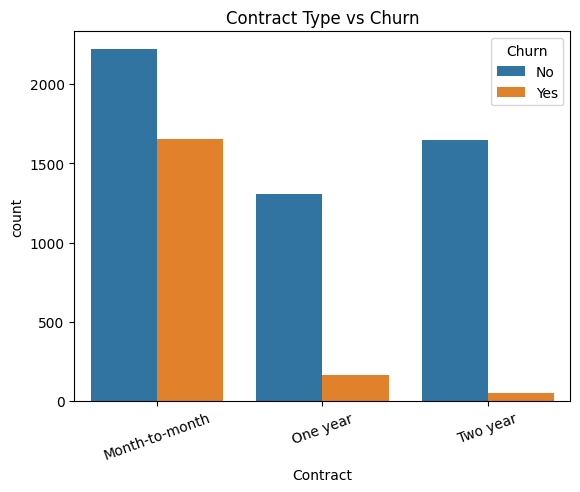

In [10]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.xticks(rotation=20)

plt.title("Contract Type vs Churn")

plt.show()

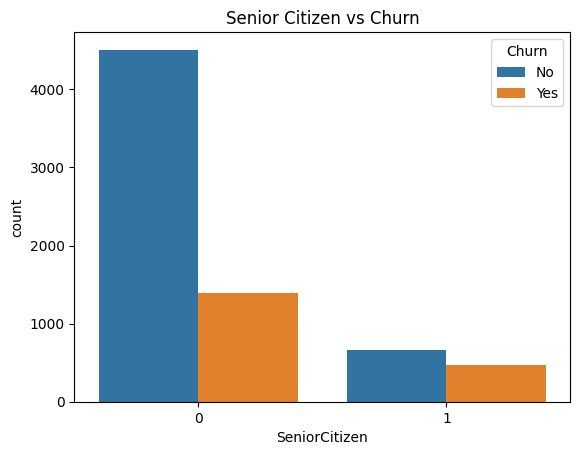

In [11]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Churn")

plt.show()

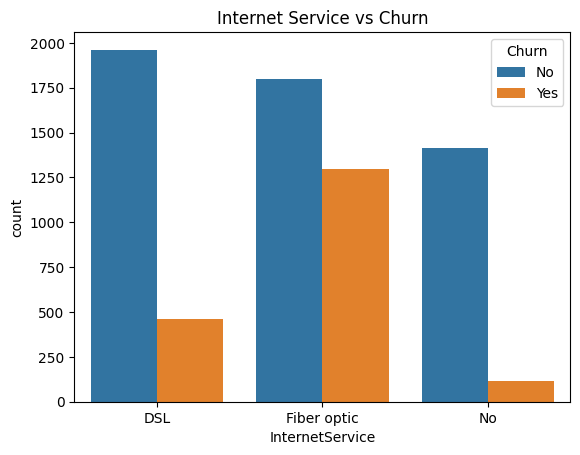

In [12]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Churn")

plt.show()

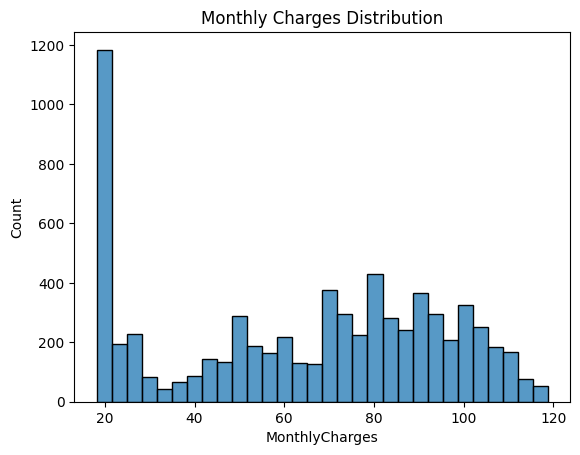

In [13]:
sns.histplot(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")

plt.show()

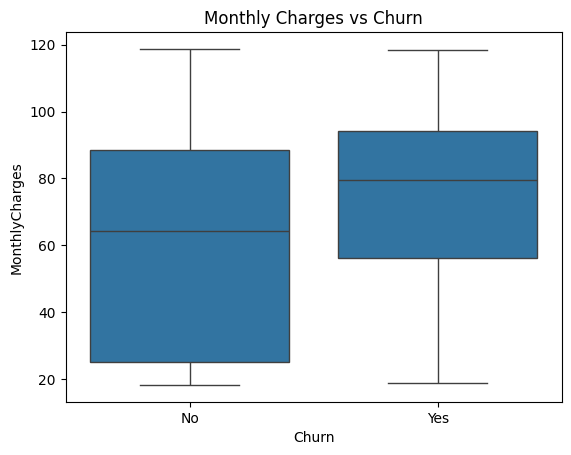

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [20]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [21]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

C:\Users\admin\AppData\Local\Temp\ipykernel_15964\1685388760.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

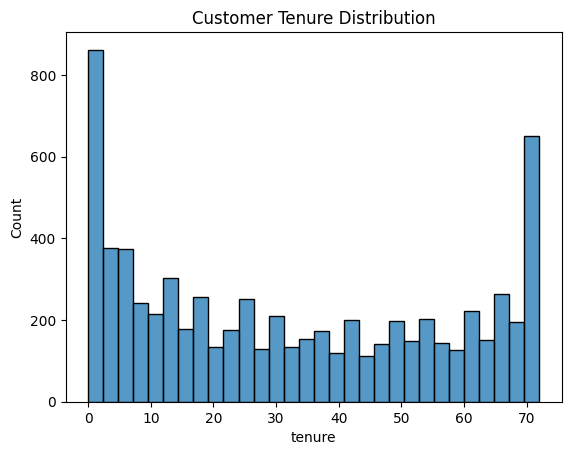

In [22]:
sns.histplot(df['tenure'], bins=30)

plt.title("Customer Tenure Distribution")

plt.show()

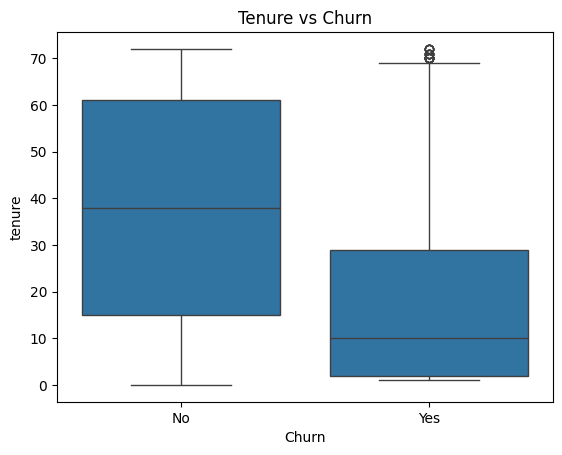

In [23]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

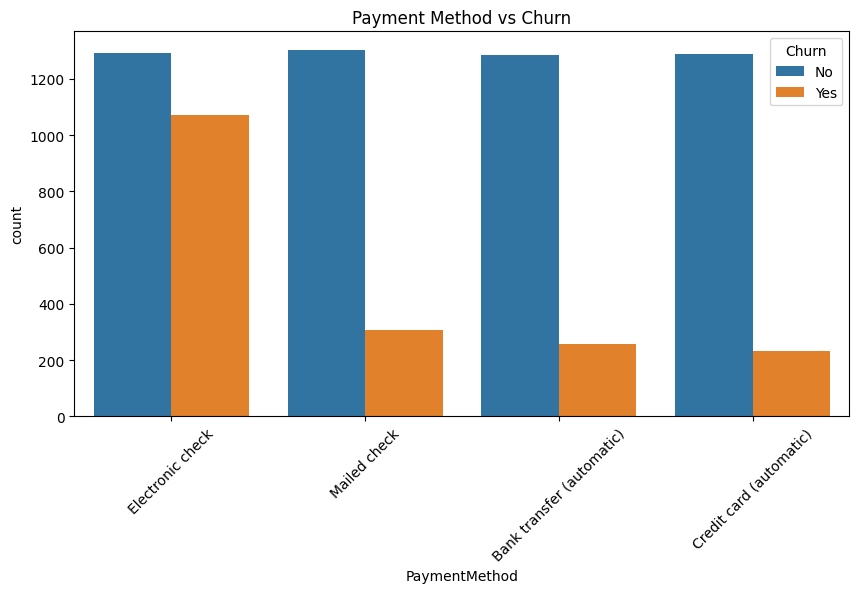

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

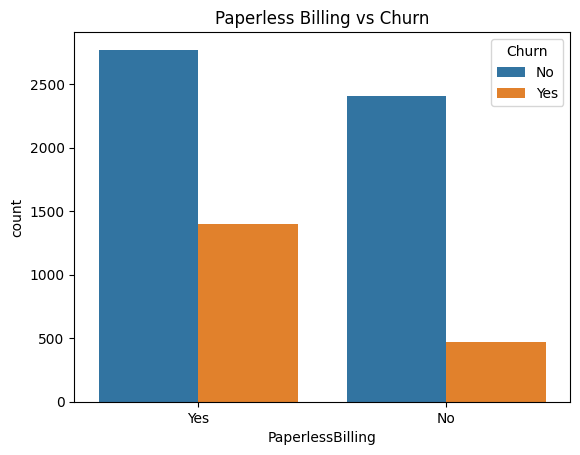

In [25]:
sns.countplot(
    x='PaperlessBilling',
    hue='Churn',
    data=df
)

plt.title("Paperless Billing vs Churn")

plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\admin\AppData\Local\Temp\ipykernel_15964\3207929033.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [27]:
corr = df.corr()

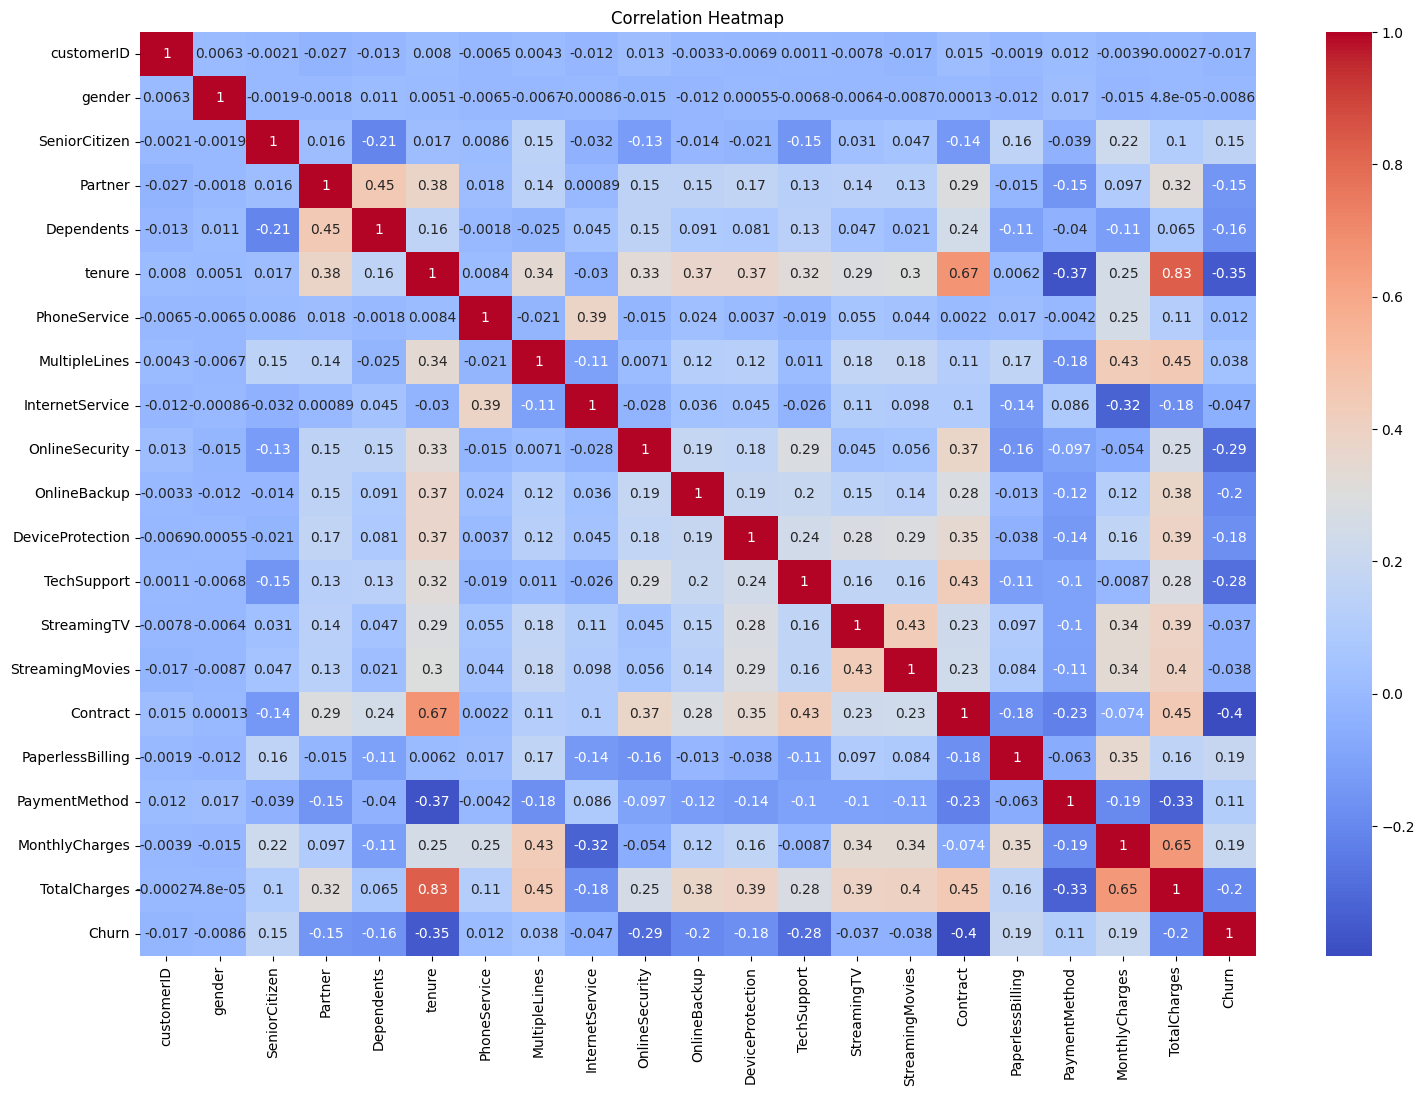

In [28]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

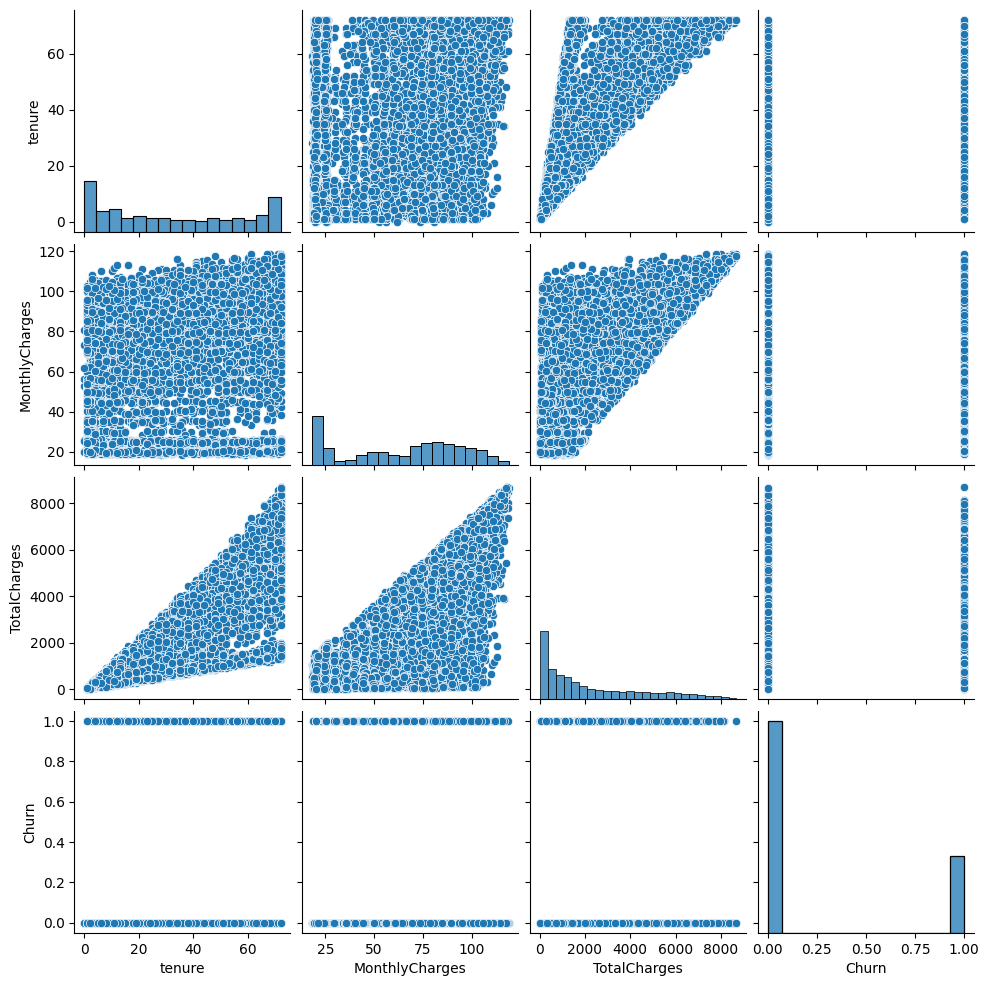

In [29]:
sns.pairplot(
    df[['tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn']]
)

plt.show()

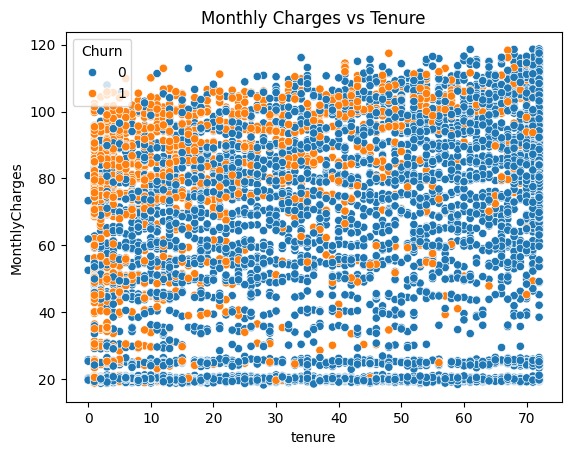

In [30]:
sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)

plt.title("Monthly Charges vs Tenure")

plt.show()